# URA Rental Imputation — 4 Methods Comparison
**Config:** MCAR | seed=123 | miss_rate=25%

| Method | Type | Interval |
|--------|------|----------|
| Linear Interpolation | Classical baseline | ❌ |
| KNN Imputer | Classical baseline | ❌ |
| VAE | Deep generative | ✅ posterior draws |
| SAITS | Self-attention | ✅ MC-dropout |

## 0 — Install & Imports

In [1]:
import subprocess, sys
def pip_install(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

pip_install('pypots')
print("Installs complete.")

Installs complete.


In [2]:
import re, calendar, time, warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import KNNImputer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

try:
    from pypots.imputation import SAITS
    SAITS_AVAIL = True
except ImportError:
    SAITS_AVAIL = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_theme(style='whitegrid', palette='muted')

print(f"PyTorch {torch.__version__} | Device: {DEVICE}")
print(f"SAITS/pypots: {SAITS_AVAIL}")


████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 

PyTorch 2.5.1+cu121 | Device: cuda
SAITS/pypots: True


## 1 — Config

In [ ]:
SEED         = 123
MISS_RATE    = 0.25
REGIME       = 'MCAR'
N_POSTERIOR  = 30
N_VAE_EPOCHS = 150
MASK_PATH    = f'mcar_mask_seed{SEED}_rate{int(MISS_RATE*100)}_v2_new.npz'
DATA_PATH    = r'dataset\URA_merged_full_v3_new_removed_outliers.csv'
N_SIZE_BUCKETS = 5
DEBUG_SIZE_BUCKETS = True  # Set False to hide the size-bucket explanation table
PSF_REASONABLE_RANGE = (0.5, 40.0)

print(f"Seed={SEED} | Miss rate={MISS_RATE:.0%} | Regime={REGIME}")
print(f"Mask file  : {MASK_PATH}")
print(f"Data file  : {DATA_PATH}")

Seed=123 | Miss rate=25% | Regime=MCAR
Mask file  : mcar_mask_seed123_rate25_v2_new.npz
Data file  : ../data_prep/URA_full/URA_merged_full_v3_new_removed_outliers.csv


## 2 — Helper Functions

In [4]:
def norm_name(x):
    return re.sub(r'[^a-z0-9]+', '', str(x).lower())

def pick_col(df, candidates, required=False):
    norm_map = {norm_name(c): c for c in df.columns}
    for cand in candidates:
        nc = norm_name(cand)
        if nc in norm_map:
            return norm_map[nc]
    for cand in candidates:
        nc = norm_name(cand)
        for k, v in norm_map.items():
            if nc in k or k in nc:
                return v
    if required:
        raise KeyError(f"Required column not found. Tried: {candidates}")
    return None

def clean_num(series):
    if series is None:
        return pd.Series(dtype='float64')
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce').astype(float)
    s0 = series.astype(str).str.strip()
    rng2 = s0.str.extract(r'^\s*(-?\d+(?:\.\d+)?)\s*(?:to|-|\u2013|\u2014)\s*(-?\d+(?:\.\d+)?)\s*$')
    midpoint = (pd.to_numeric(rng2[0], errors='coerce') + pd.to_numeric(rng2[1], errors='coerce')) / 2.0
    s = s0.str.replace(',', '', regex=False)
    s = s.str.replace(r'[^0-9.\-]+', '', regex=True)
    s = s.replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
    out = pd.to_numeric(s, errors='coerce')
    out = out.where(midpoint.isna(), midpoint)
    return out.astype(float)

def parse_month(series):
    if series is None:
        return pd.Series(dtype='float64')
    out = clean_num(series)
    if out.notna().mean() > 0.8:
        return out
    s = series.astype(str).str.strip().str.lower()
    month_map = {m.lower(): i for i, m in enumerate(calendar.month_name) if m}
    month_map.update({m.lower(): i for i, m in enumerate(calendar.month_abbr) if m})
    return pd.to_numeric(out.fillna(s.map(month_map)), errors='coerce')

def convert_range_to_number(range_str):
    if pd.isna(range_str) or not isinstance(range_str, str):
        return np.nan
    parts = range_str.replace(',', '').split(' to ')
    try:
        nums = [float(p) for p in parts]
        return sum(nums) / len(nums)
    except:
        return np.nan

def make_size_bucket(area_sqft, q=3):
    """Assign each transaction to a relative floor-area bucket: SZ1=smallest, SZq=largest.

    The buckets are global quantile buckets, so with q=5 the notebook tries to put
    roughly 20% of valid transactions in each size tier. Missing areas are assigned
    to SZ1 at the end so every row still belongs to one project-size series.
    """
    s_valid = area_sqft.dropna()
    out = pd.Series(index=area_sqft.index, dtype='object')
    if s_valid.nunique() < 2:
        out[:] = 'SZ1'
        return out

    # If the data has fewer distinct area values than requested buckets, reduce q.
    q_use = min(q, int(s_valid.nunique()))
    lab_use = [f'SZ{i+1}' for i in range(q_use)]
    try:
        # qcut creates equal-frequency buckets. Ranking first breaks ties so repeated
        # floor-area values do not collapse bucket edges and drop labels unpredictably.
        buckets = pd.qcut(s_valid.rank(method='first'), q=q_use, labels=lab_use, duplicates='drop')
    except Exception:
        # Fallback: equal-width buckets by raw sqft if quantile bucketing fails.
        buckets = pd.cut(s_valid, bins=q_use, labels=lab_use, include_lowest=True, duplicates='drop')
    out.loc[s_valid.index] = buckets.astype(str)
    return out.fillna('SZ1')

def explain_size_buckets(area_sqft, buckets):
    """Show how make_size_bucket split the data."""
    tmp = pd.DataFrame({'area_sqft': area_sqft, 'size_bucket': buckets})
    summary = (tmp.groupby('size_bucket', dropna=False)['area_sqft']
                 .agg(rows='size', missing_area=lambda s: s.isna().sum(),
                      min_sqft='min', median_sqft='median', max_sqft='max')
                 .sort_index())
    print('Size bucket meaning: SZ1 = smallest floor areas; larger SZ number = larger floor areas.')
    print(f'Requested buckets: {N_SIZE_BUCKETS}; actual buckets shown: {summary.shape[0]}')
    display(summary)
    return summary

# Scaler helpers
def fit_obs_scaler(X_data, M_obs):
    obs = X_data[M_obs == 1].reshape(-1, 1)
    return StandardScaler().fit(obs)

def scale_obs(X_data, sc):
    out = np.zeros_like(X_data, dtype=float)
    fin = ~np.isnan(X_data)
    out[fin] = sc.transform(X_data[fin].reshape(-1, 1)).ravel()
    return out

def unscale(X_sc, sc):
    out = np.full_like(X_sc, np.nan, dtype=float)
    fin = np.isfinite(X_sc)
    out[fin] = sc.inverse_transform(X_sc[fin].reshape(-1, 1)).ravel()
    return out

print("Helper functions defined.")

Helper functions defined.


## 3 — Load Data & Build Panel

In [5]:
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8')
print(f"Loaded: {len(df_raw):,} rows")

df_raw['Area_Cleaned'] = df_raw['Floor Area (SQFT)'].apply(convert_range_to_number)
df_raw['Rent_PSF']     = df_raw['Monthly Rent ($)'] / df_raw['Area_Cleaned']
df_raw['Date_DT']      = pd.to_datetime(df_raw['Lease Commencement Date'])
df_raw['Year']         = df_raw['Date_DT'].dt.year
df_raw['Month']        = df_raw['Date_DT'].dt.month

project_col  = pick_col(df_raw, ['Project Name', 'Project', 'Development', 'Property Name'], required=True)
year_col     = pick_col(df_raw, ['Year'], required=True)
month_col    = pick_col(df_raw, ['Month'], required=True)
bedroom_col  = pick_col(df_raw, ['No of Bedroom', 'Bedrooms', 'Bedroom'], required=True)
rent_psf_col = pick_col(df_raw, ['Rent_PSF', 'Rent PSF', 'Rent per sqft'], required=True)
rent_col     = pick_col(df_raw, ['Monthly Rent ($)', 'Monthly Rent', 'Rent'])
area_sqft_col= pick_col(df_raw, ['Area_Cleaned', 'Floor Area (SQFT)', 'Area_sqft'])
area_sqm_col = pick_col(df_raw, ['Floor Area (sqm)', 'Area_sqm'])
district_col = pick_col(df_raw, ['Postal District', 'District'])
age_col      = pick_col(df_raw, ['Condo_Age_2026', 'house_age_2026', 'Building_Age', 'Age'])
lat_col      = pick_col(df_raw, ['Latitude', 'Lat'])
lon_col      = pick_col(df_raw, ['Longitude', 'Lon', 'Lng'])

# Filter CCR districts (1,2,9,10,11) if district column exists
if district_col:
    df_raw = df_raw[pd.to_numeric(df_raw[district_col], errors='coerce').isin([1,2,9,10,11])].copy()
    print(f"Filtered to CCR districts: {len(df_raw):,} rows")

df = pd.DataFrame({
    'project_name': df_raw[project_col].astype(str).str.strip(),
    'year':    clean_num(df_raw[year_col]).round(),
    'month':   parse_month(df_raw[month_col]).round(),
    'bedroom': clean_num(df_raw[bedroom_col]).round(),
    'rent_psf':clean_num(df_raw[rent_psf_col]),
})
df['rent']      = clean_num(df_raw[rent_col])       if rent_col       else np.nan
df['area_sqft'] = clean_num(df_raw[area_sqft_col])  if area_sqft_col  else np.nan
df['area_sqm']  = clean_num(df_raw[area_sqm_col])   if area_sqm_col   else np.nan
df['district']  = clean_num(df_raw[district_col]).round() if district_col else np.nan
df['age']       = clean_num(df_raw[age_col])         if age_col        else np.nan
df['lat']       = clean_num(df_raw[lat_col])         if lat_col        else np.nan
df['lon']       = clean_num(df_raw[lon_col])         if lon_col        else np.nan

# Repair area & rent_psf
sqft_from_sqm = df['area_sqm'] * 10.7639
bad_sqft  = ~df['area_sqft'].between(100, 10000)
good_sqm  = sqft_from_sqm.between(100, 10000)
if (bad_sqft & good_sqm).any():
    df.loc[bad_sqft & good_sqm, 'area_sqft'] = sqft_from_sqm[bad_sqft & good_sqm]
    print(f"Repaired {(bad_sqft & good_sqm).sum()} area_sqft from sqm")

calc_psf  = df['rent'] / df['area_sqft']
bad_psf   = df['rent_psf'].isna() | ~df['rent_psf'].between(*PSF_REASONABLE_RANGE)
repair_psf = calc_psf.notna() & bad_psf
if repair_psf.any():
    df.loc[repair_psf, 'rent_psf'] = calc_psf[repair_psf]
    print(f"Repaired {repair_psf.sum()} rent_psf values")

valid_mask = (
    df['project_name'].ne('') &
    df['year'].between(2000, 2030) &
    df['month'].between(1, 12) &
    df['rent_psf'].between(*PSF_REASONABLE_RANGE)
)
df = df.loc[valid_mask].copy()
df['year']  = df['year'].astype(int)
df['month'] = df['month'].astype(int)

df['size_bucket']  = make_size_bucket(df['area_sqft'], q=N_SIZE_BUCKETS) if df['area_sqft'].notna().any() else 'SZ1'
if DEBUG_SIZE_BUCKETS:
    size_bucket_summary = explain_size_buckets(df['area_sqft'], df['size_bucket'])

df['YearMonth']    = pd.to_datetime(df[['year','month']].assign(day=1)).dt.to_period('M').astype(str)
df['ProjectSeries']= df['project_name'] + ' | ' + df['size_bucket']

agg = (df.groupby(['ProjectSeries','project_name','size_bucket','YearMonth'], as_index=False)
         .agg(Rent_PSF_mean=('rent_psf','mean'), n_tx=('rent_psf','size'),
              Area_sqft_med=('area_sqft','median'), Lat=('lat','median'),
              Lon=('lon','median'), District=('district','median'), Age=('age','median')))
agg['bedroom'] = 0

all_projects = sorted(agg['ProjectSeries'].unique())
all_months   = sorted(agg['YearMonth'].unique())
all_bedrooms = [0]
P, T, B      = len(all_projects), len(all_months), len(all_bedrooms)

proj_idx  = {p: i for i, p in enumerate(all_projects)}
month_idx = {m: j for j, m in enumerate(all_months)}
br_idx    = {b: k for k, b in enumerate(all_bedrooms)}

series_meta = (agg[['ProjectSeries','project_name','size_bucket','Area_sqft_med','Lat','Lon','District','Age']]
               .drop_duplicates('ProjectSeries').set_index('ProjectSeries').reindex(all_projects))

X_full = np.full((P, T, B), np.nan, dtype=np.float32)
N_tx   = np.zeros((P, T, B), dtype=np.float32)
M_full = np.zeros((P, T, B), dtype=np.float32)

for _, row in agg.iterrows():
    p = proj_idx[row['ProjectSeries']]
    t = month_idx[row['YearMonth']]
    b = br_idx[row['bedroom']]
    X_full[p, t, b] = row['Rent_PSF_mean']
    M_full[p, t, b] = 1.0
    N_tx[p, t, b]   = row['n_tx'] if pd.notna(row['n_tx']) else 1.0

meta_df = pd.DataFrame({
    'project':        all_projects,
    'district':       series_meta['District'].fillna(-1).astype(int).values,
    'size_tier':      series_meta['size_bucket'].fillna('SZ1').values,
    'segment':        ['luxury' if d in [9,10,11] else 'mass'
                        for d in series_meta['District'].fillna(0).astype(int)],
    'n_transactions': N_tx.sum(axis=(1,2)).astype(int),
    'avg_psf':        np.round(np.nanmean(X_full, axis=(1,2)), 2),
})

SPARSITY = np.isnan(X_full).mean()
print(f"\nPanel shape      : {X_full.shape}  (projects x months x size-buckets)")
print(f"Natural sparsity : {SPARSITY:.1%}")
print("\nProject metadata (first 5):")
display(meta_df.head())

Loaded: 1,260,795 rows
Filtered to CCR districts: 381,467 rows

Panel shape      : (2259, 313, 1)  (projects x months x size-buckets)
Natural sparsity : 76.8%

Project metadata (first 5):


,project,district,size_tier,segment,n_transactions,avg_psf
0,1 MOULMEIN RISE | SZ3,11,SZ3,luxury,149,4.17
1,1 NASSIM | SZ4,10,SZ4,luxury,11,3.49
2,1 NASSIM | SZ5,10,SZ5,luxury,54,2.76
3,10 EVELYN | SZ1,11,SZ1,luxury,15,7.42
4,10 EVELYN | SZ2,11,SZ2,luxury,16,6.68


## 4 — MCAR Masking (save / load)

In [6]:
def mask_mcar(X_full, miss_rate, seed):
    rng  = np.random.RandomState(seed)
    obs  = ~np.isnan(X_full)
    hide = obs & (rng.rand(*X_full.shape) < miss_rate)
    M_obs   = (obs & ~hide).astype(float)
    M_test  = hide.astype(float)
    X_train = X_full.copy()
    X_train[M_test == 1] = np.nan
    return X_train, M_obs, M_test

if os.path.exists(MASK_PATH):
    print(f"Loading saved mask from {MASK_PATH} ...")
    m       = np.load(MASK_PATH)
    X_train = m['X_train']
    M_obs   = m['M_obs']
    M_test  = m['M_test']
else:
    print(f"Generating new MCAR mask (seed={SEED}, rate={MISS_RATE:.0%}) and saving ...")
    X_train, M_obs, M_test = mask_mcar(X_full, MISS_RATE, SEED)
    np.savez_compressed(MASK_PATH, X_train=X_train, M_obs=M_obs, M_test=M_test)
    print(f"Saved → {MASK_PATH}")

print(f"\nX_train shape : {X_train.shape}")
print(f"Train cells   : {int(M_obs.sum()):,}")
print(f"Test cells    : {int(M_test.sum()):,}")
print(f"Actual miss   : {M_test.sum()/(M_obs.sum()+M_test.sum()):.1%}")

Generating new MCAR mask (seed=123, rate=25%) and saving ...
Saved → mcar_mask_seed123_rate25_v2_new.npz

X_train shape : (2259, 313, 1)
Train cells   : 122,948
Test cells    : 40,918
Actual miss   : 25.0%


## 5 — Evaluation Helpers

In [8]:
def eval_point(X_imp, M_test, X_full, model, elapsed):
    mask = M_test == 1
    yt, yp = X_full[mask], X_imp[mask]
    valid  = ~np.isnan(yp)
    yt, yp = yt[valid], yp[valid]
    return dict(model=model,
                RMSE=np.sqrt(mean_squared_error(yt, yp)),
                MAE=mean_absolute_error(yt, yp),
                MAPE=np.mean(np.abs((yt-yp)/(np.abs(yt)+1e-6)))*100,
                R2=r2_score(yt, yp),
                elapsed_s=elapsed)

def eval_interval(draws, M_test, X_full):
    if not draws:
        return np.nan
    mask = M_test == 1
    yt   = X_full[mask]
    mat  = np.stack([d[mask] for d in draws])   # (n_draws, N_test)
    lo   = np.percentile(mat, 5,  axis=0)
    hi   = np.percentile(mat, 95, axis=0)
    return float(np.mean((yt >= lo) & (yt <= hi)) * 100)

print("Evaluation helpers defined.")

Evaluation helpers defined.


## 6 — Linear Interpolation
Interpolate linearly between observed months within the same project-size series, then ffill/bfill for the remaining ends.

In [9]:
def run_linear_interp(X_data, M_obs, seed=None):
    'Linear interpolation + ffill/bfill per (project, size-bucket) series.'
    P_, T_, B_ = X_data.shape
    X_out = np.full_like(X_data, np.nan)
    for p in range(P_):
        for b in range(B_):
            s = pd.Series(X_data[p, :, b].copy())
            s_interp = (
                s.interpolate(method='linear', limit_direction='both')
                 .ffill()
                 .bfill()
            )
            for t in range(T_):
                if M_obs[p, t, b] == 1:
                    X_out[p, t, b] = X_data[p, t, b]   # keep the train value unchanged
                else:
                    X_out[p, t, b] = s_interp.iloc[t]  # Use interpolated values

    # Global fallback for cells that are still NaN (projects with absolutely no data).
    gm = np.nanmean(X_data[M_obs == 1])
    X_out = np.where(np.isnan(X_out), gm, X_out)
    return X_out, []   # no posterior draws

print('run_linear_interp() defined.')

run_linear_interp() defined.


## 7 — KNN Imputer
Two-way KNN: imputes along both the project axis and the month axis, then takes the average, allowing for the borrowing of information from both similar projects and similar months.

In [10]:
def stabilise_for_sklearn(mat):
    'Fill all-NaN rows/cols with mean so that KNNImputer doesn\'t throw an error.'
    mat = mat.copy()
    gm = np.nanmean(mat)
    if np.isnan(gm): gm = 0.0
    col_mean = np.nanmean(mat, axis=0)
    col_mean = np.where(np.isnan(col_mean), gm, col_mean)
    row_mean = np.nanmean(mat, axis=1)
    row_mean = np.where(np.isnan(row_mean), gm, row_mean)
    for i in range(mat.shape[0]):
        if np.all(np.isnan(mat[i, :])):
            mat[i, :] = col_mean
    for j in range(mat.shape[1]):
        if np.all(np.isnan(mat[:, j])):
            mat[:, j] = row_mean
    return mat

def run_knn(X_data, M_obs, seed=None, k=5):
    'Two-way KNN imputation: row-wise + col-wise, then average.'
    P_, T_, B_ = X_data.shape
    X_out = np.full_like(X_data, np.nan)
    for b in range(B_):
        sl  = X_data[:, :, b].copy()        # (P, T)
        sl0 = stabilise_for_sklearn(sl)
        row_imp = KNNImputer(n_neighbors=k, weights='distance').fit_transform(sl0)       # row = project
        col_imp = KNNImputer(n_neighbors=k, weights='distance').fit_transform(sl0.T).T   # row = month
        X_hat = np.nanmean(np.stack([row_imp, col_imp]), axis=0)
        X_out[:, :, b] = np.where(M_obs[:, :, b] == 1, X_data[:, :, b], X_hat)
    return X_out, []   # no posterior draws

print('run_knn() defined. k=5 (two-way: project-axis + month-axis).')

run_knn() defined. k=5 (two-way: project-axis + month-axis).


## 8 — VAE

In [11]:
class VAEEnc(nn.Module):
    def __init__(self, p, z=8, h=128, drop=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(p*2, h), nn.LayerNorm(h), nn.LeakyReLU(0.2), nn.Dropout(drop),
            nn.Linear(h, h),   nn.LayerNorm(h), nn.LeakyReLU(0.2), nn.Dropout(drop),
        )
        self.mu = nn.Linear(h, z)
        self.lv = nn.Linear(h, z)

    def forward(self, x, m):
        h = self.net(torch.cat([x*m, m], dim=1))
        return self.mu(h), torch.clamp(self.lv(h), -10, 10)

class VAEDec(nn.Module):
    def __init__(self, p, z=8, h=128, drop=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z, h), nn.LayerNorm(h), nn.LeakyReLU(0.2), nn.Dropout(drop),
            nn.Linear(h, h), nn.LayerNorm(h), nn.LeakyReLU(0.2), nn.Dropout(drop),
            nn.Linear(h, p),
        )
    def forward(self, z): return self.net(z)

def run_vae(X_data, M_obs, seed, z_dim=8, beta=0.1, epochs=N_VAE_EPOCHS,
            lr=1e-3, h=128, warmup=50, free_bits=0.5, batch=32,
            n_draws=N_POSTERIOR, device=DEVICE):
    torch.manual_seed(seed); np.random.seed(seed)
    sc  = fit_obs_scaler(X_data, M_obs)
    Xsc = scale_obs(X_data, sc)
    P_, T_, B_ = X_data.shape
    vms = {}
    for b in range(B_):
        xs     = torch.FloatTensor(Xsc[:,:,b].T).to(device)   # (T, P)
        ms     = torch.FloatTensor(M_obs[:,:,b].T).to(device)
        loader = DataLoader(TensorDataset(xs, ms), batch_size=batch, shuffle=True)
        enc    = VAEEnc(P_, z_dim, h).to(device)
        dec    = VAEDec(P_, z_dim, h).to(device)
        params = list(enc.parameters()) + list(dec.parameters())
        opt    = optim.Adam(params, lr=lr)
        sch    = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=50, T_mult=2)
        for ep in range(1, epochs+1):
            enc.train(); dec.train()
            bt = beta * min(1.0, ep/max(1, warmup))
            for xb, mb in loader:
                xb, mb  = xb.to(device), mb.to(device)
                mu, lv  = enc(xb, mb)
                z       = mu + torch.exp(0.5*lv) * torch.randn_like(mu)
                xhat    = dec(z)
                recon   = ((xhat-xb)**2 * mb).sum() / (mb.sum()+1e-8)
                kl      = torch.clamp(-0.5*(1+lv-mu.pow(2)-lv.exp()), min=free_bits).mean()
                loss    = recon + bt*kl
                opt.zero_grad(set_to_none=True); loss.backward()
                nn.utils.clip_grad_norm_(params, 1.0); opt.step(); sch.step()
        vms[b] = (enc, dec, sc)

    draws = []
    for _ in range(n_draws):
        Xout = X_data.copy()
        for b in range(B_):
            enc, dec, sc = vms[b]
            enc.eval(); dec.eval()
            xs = torch.FloatTensor(scale_obs(X_data, sc)[:,:,b].T).to(device)
            ms = torch.FloatTensor(M_obs[:,:,b].T).to(device)
            with torch.no_grad():
                mu, lv = enc(xs, ms)
                z      = mu + torch.exp(0.5*lv) * torch.randn_like(mu)
                pr     = dec(z).cpu().numpy()
            pr_orig = unscale(pr.T, sc)
            missing = M_obs[:,:,b] == 0
            Xout[:,:,b][missing] = pr_orig[missing]
        draws.append(Xout)

    X_imp = np.nanmean(np.stack(draws), axis=0)
    return X_imp, draws

print("VAE defined.")

VAE defined.


## 9 — SAITS

In [15]:
def _saits_lininterp_fallback(X_data, M_obs, seed):
    from scipy.interpolate import interp1d
    X_imp = X_data.copy()
    P_, T_, B_ = X_data.shape
    for p in range(P_):
        for b in range(B_):
            s   = X_data[p, :, b].copy()
            obs = np.where(~np.isnan(s))[0]
            if len(obs) >= 2:
                f   = interp1d(obs, s[obs], kind='linear', fill_value='extrapolate', bounds_error=False)
                nan = np.where(np.isnan(s))[0]
                X_imp[p, nan, b] = f(nan)
            elif len(obs) == 1:
                X_imp[p, np.isnan(s), b] = s[obs[0]]
    return X_imp, []

def run_saits(X_data, M_obs, seed, n_layers=2, d_model=64, d_ffn=128,
              n_heads=4, d_k=16, d_v=16, dropout=0.1, epochs=100,
              n_draws=N_POSTERIOR, device=DEVICE):
    if not SAITS_AVAIL:
        print("    [SAITS] pypots unavailable — linear interp fallback.")
        return _saits_lininterp_fallback(X_data, M_obs, seed)

    np.random.seed(seed); torch.manual_seed(seed)
    P_, T_, B_ = X_data.shape

    # pypots expects a missing_mask where 1 indicates a missing value.
    # M_obs is the observation mask (1=observed, 0=missing), so we invert it.
    missing_mask = 1 - M_obs

    saits = SAITS(
        n_steps=T_, n_features=B_,
        n_layers=n_layers, d_model=d_model, d_ffn=d_ffn,
        n_heads=n_heads, d_k=d_k, d_v=d_v,
        dropout=dropout, epochs=epochs, patience=15,
        batch_size=min(32, P_), device=device, saving_path=None, verbose=False,
    )
    # FIX: Provide 'missing_mask' to avoid KeyError.
    train_set_dict = {"X": X_data.copy(), "missing_mask": missing_mask}
    saits.fit(train_set_dict)

    # For consistency, provide the mask to predict as well.
    test_set_dict = {"X": X_data.copy(), "missing_mask": missing_mask}
    X_imp = saits.predict(test_set_dict)["imputation"]

    # --- MC-dropout draws (Corrected implementation) ---
    saits.model.train()
    # Prepare the input dictionary once, as expected by the pypots model's forward pass.
    X_torch = torch.from_numpy(X_data.copy()).float().to(device)
    mask_torch = torch.from_numpy(missing_mask).float().to(device)
    model_input = {"X": X_torch, "missing_mask": mask_torch}
    draws = []
    for _ in range(n_draws):
        with torch.no_grad():
            # Call the model's forward pass directly to ensure dropout is active.
            imputation_tensor = saits.model(model_input)["imputation"]
            draws.append(imputation_tensor.cpu().numpy())
    saits.model.eval()

    return X_imp, draws

print(f"SAITS defined. pypots available: {SAITS_AVAIL}")

SAITS defined. pypots available: True


## 10 — Run All 4 Methods

In [16]:
METHOD_REGISTRY = {
    'Linear Interp': run_linear_interp,
    'KNN':           run_knn,
    'VAE':           run_vae,
    'SAITS':         run_saits,
}

RESULTS    = []
IMP_OUTPUT = {}   # Save X_imp for later use.

for name, runner in METHOD_REGISTRY.items():
    print(f"\n{'='*50}")
    print(f"Running {name} | seed={SEED} | MCAR {MISS_RATE:.0%}")
    print('='*50)
    t0 = time.time()
    try:
        Xi, draws = runner(X_train, M_obs, SEED)
    except Exception as exc:
        print(f"  [{name}] FAILED: {exc}")
        continue
    elapsed = time.time() - t0

    res         = eval_point(Xi, M_test, X_full, name, elapsed)
    res['PI90'] = eval_interval(draws, M_test, X_full)
    RESULTS.append(res)
    IMP_OUTPUT[name] = Xi

    pi_str = f"PI90={res['PI90']:.1f}%" if not np.isnan(res['PI90']) else "PI90=N/A"
    print(f"  RMSE={res['RMSE']:.3f}  MAE={res['MAE']:.3f}  "
          f"MAPE={res['MAPE']:.2f}%  R2={res['R2']:.3f}  "
          f"{pi_str}  ({elapsed:.1f}s)")

print("\n=== Summary ===")
df_res = pd.DataFrame(RESULTS)
display(df_res[['model','RMSE','MAE','MAPE','R2','PI90','elapsed_s']].round(4))


Running Linear Interp | seed=123 | MCAR 25%
  RMSE=0.504  MAE=0.356  MAPE=9.42%  R2=0.871  PI90=N/A  (2.7s)

Running KNN | seed=123 | MCAR 25%
  RMSE=0.458  MAE=0.327  MAPE=8.68%  R2=0.893  PI90=N/A  (9.1s)

Running VAE | seed=123 | MCAR 25%


2026-04-27 10:01:42 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.


  RMSE=0.431  MAE=0.306  MAPE=8.16%  R2=0.906  PI90=37.8%  (6.4s)

Running SAITS | seed=123 | MCAR 25%
  RMSE=0.423  MAE=0.298  MAPE=7.81%  R2=0.909  PI90=0.0%  (520.1s)

=== Summary ===


,model,RMSE,MAE,MAPE,R2,PI90,elapsed_s
0,Linear Interp,0.5042,0.3557,9.4214,0.8712,NaN,2.6572
1,KNN,0.4585,0.3267,8.6848,0.8935,NaN,9.0972
2,VAE,0.4313,0.3065,8.1607,0.9057,37.756,6.4327
3,SAITS,0.4231,0.2981,7.8119,0.9093,0.000,520.0650


In [17]:
df_res = pd.DataFrame(RESULTS).sort_values('RMSE').reset_index(drop=True)
display(df_res[['model','RMSE','MAE','MAPE','R2','PI90','elapsed_s']].round(4))

,model,RMSE,MAE,MAPE,R2,PI90,elapsed_s
0,SAITS,0.4231,0.2981,7.8119,0.9093,0.000,520.0650
1,VAE,0.4313,0.3065,8.1607,0.9057,37.756,6.4327
2,KNN,0.4585,0.3267,8.6848,0.8935,NaN,9.0972
3,Linear Interp,0.5042,0.3557,9.4214,0.8712,NaN,2.6572


## 11 — Before vs After Comparison

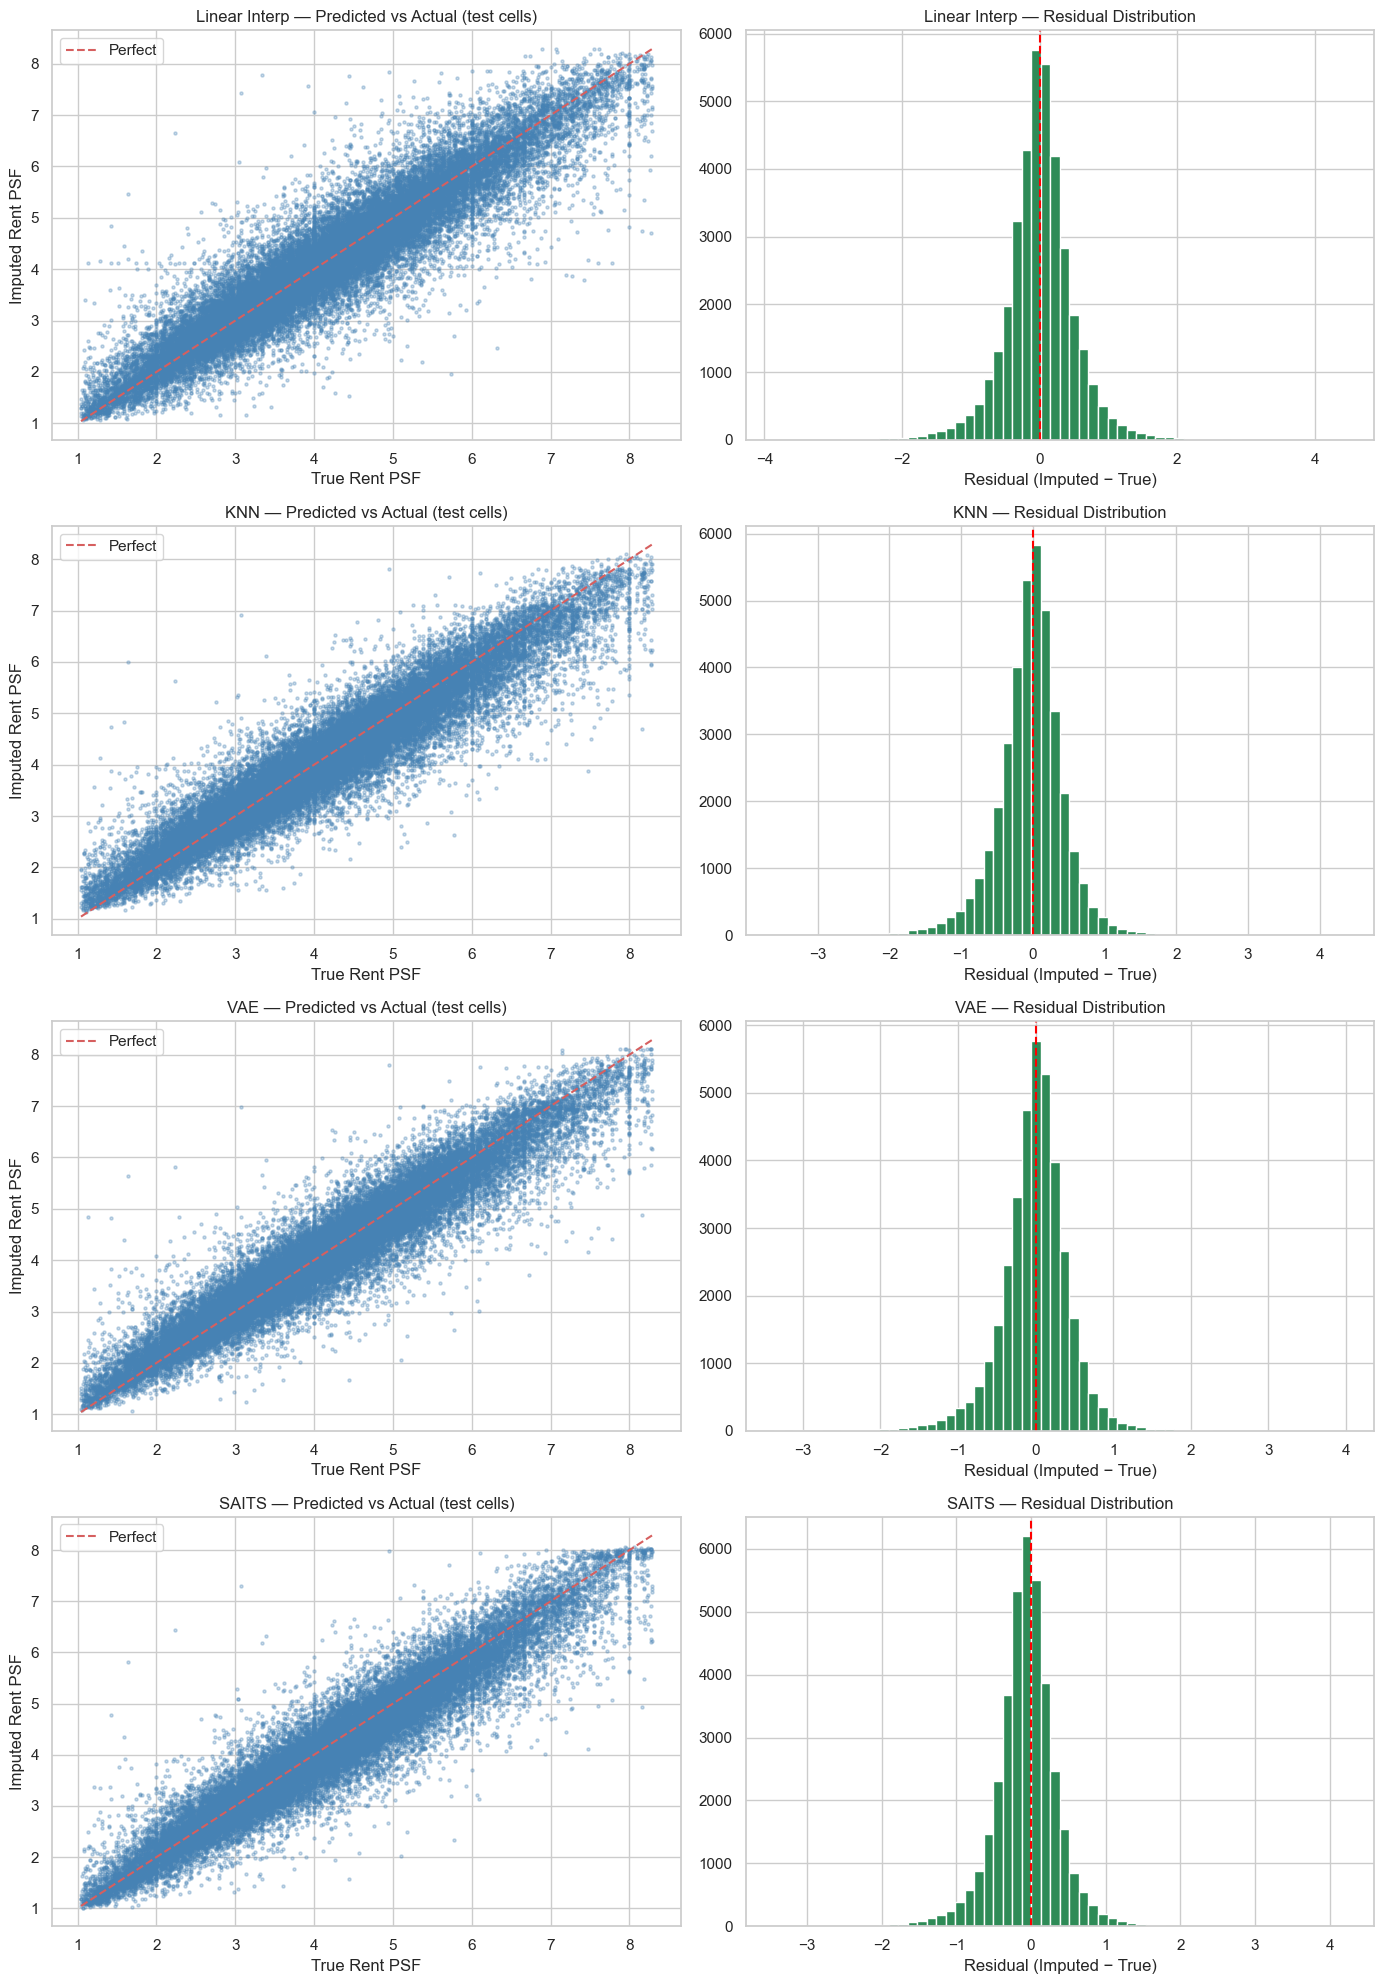

In [13]:
fig, axes = plt.subplots(len(IMP_OUTPUT), 2, figsize=(14, 5*len(IMP_OUTPUT)))
if len(IMP_OUTPUT) == 1:
    axes = [axes]

test_mask = M_test == 1
true_vals = X_full[test_mask]

for row_idx, (name, Xi) in enumerate(IMP_OUTPUT.items()):
    pred_vals = Xi[test_mask]
    valid     = ~np.isnan(pred_vals)

    # Scatter: predicted vs actual
    axes[row_idx][0].scatter(true_vals[valid], pred_vals[valid],
                              alpha=0.3, s=5, color='steelblue')
    lim = [true_vals[valid].min(), true_vals[valid].max()]
    axes[row_idx][0].plot(lim, lim, 'r--', lw=1.5, label='Perfect')
    axes[row_idx][0].set_xlabel('True Rent PSF'); axes[row_idx][0].set_ylabel('Imputed Rent PSF')
    axes[row_idx][0].set_title(f'{name} — Predicted vs Actual (test cells)')
    axes[row_idx][0].legend()

    # Residual distribution
    residuals = pred_vals[valid] - true_vals[valid]
    axes[row_idx][1].hist(residuals, bins=60, color='seagreen', edgecolor='white')
    axes[row_idx][1].axvline(0, color='red', ls='--', lw=1.5)
    axes[row_idx][1].set_xlabel('Residual (Imputed − True)')
    axes[row_idx][1].set_title(f'{name} — Residual Distribution')

plt.tight_layout()
plt.savefig('imputation_results.png', dpi=150)
plt.show()

## 12 — Export Imputed Data

In [14]:
import joblib

bundle = {
    'seed': SEED, 'miss_rate': MISS_RATE, 'regime': REGIME,
    'X_full':  np.asarray(X_full,  dtype=np.float32),
    'X_train': np.asarray(X_train, dtype=np.float32),
    'M_obs':   np.asarray(M_obs,   dtype=np.uint8),
    'M_test':  np.asarray(M_test,  dtype=np.uint8),
    'X_imp_linear_interp': np.asarray(IMP_OUTPUT.get('Linear Interp'), dtype=np.float32),
    'X_imp_knn':   np.asarray(IMP_OUTPUT.get('KNN'),   dtype=np.float32),
    'X_imp_vae':   np.asarray(IMP_OUTPUT.get('VAE'),   dtype=np.float32),
    'X_imp_saits': np.asarray(IMP_OUTPUT.get('SAITS'), dtype=np.float32),
    'P': P, 'T': T, 'B': B,
    'all_projects': all_projects,
    'all_months':   all_months,
    'meta_df':      meta_df,
    'results':      df_res.to_dict(),
}

joblib.dump(bundle, 'ura_imputation_4methods.pkl', compress=3)
print("Saved: ura_imputation_4methods.pkl")
print(f"Keys: {sorted(bundle.keys())}")

Saved: ura_imputation_4methods.pkl
Keys: ['B', 'M_obs', 'M_test', 'P', 'T', 'X_full', 'X_imp_knn', 'X_imp_linear_interp', 'X_imp_saits', 'X_imp_vae', 'X_train', 'all_months', 'all_projects', 'meta_df', 'miss_rate', 'regime', 'results', 'seed']
